In [ ]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/interim/csecicids2018"

In [2]:
import os

for dirname, _, filenames in os.walk(DATASET_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/processed/csecicids2018\Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
../data/processed/csecicids2018\Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet


In [3]:
import pandas as pd

In [4]:
parquet_collection = []

# read parquet files into pandas dataframes
for dirname, _, filenames in os.walk(DATASET_DIR):
    for filename in filenames:
        if filename.endswith(".parquet"):
            path = os.path.join(dirname, filename)
            print(f"Reading {path}")
            # df = pd.read_parquet(path).sample(frac=0.2, replace=False, random_state=42)
            df = pd.read_parquet(path)
            parquet_collection.append(df)


Reading ../data/processed/csecicids2018\Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
Reading ../data/processed/csecicids2018\Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet


In [5]:
# # read parquet files into pandas dataframes
# df = pd.concat(parquet_collection, ignore_index=True)
# df.head(5)

# for each df, get the number of rows and calculate total number of rows
total_rows = 0
for df in parquet_collection:
    rows = df.shape[0]
    total_rows += rows
    print(f"Rows: {rows}")

print(f"Total rows: {total_rows}")

df = pd.concat(parquet_collection, ignore_index=True)

Rows: 771587
Rows: 619346
Rows: 954846
Rows: 561396
Rows: 794812
Rows: 591873
Rows: 456873
Rows: 249170
Rows: 830224
Rows: 829405
Total rows: 6659532


In [6]:
df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [7]:
# # get unique values of the 'label' column
df['Label'].unique()

array(['Benign', 'Bot', 'FTP-BruteForce', 'SSH-Bruteforce',
       'DDoS attacks-LOIC-HTTP', 'DDOS attack-LOIC-UDP',
       'DDOS attack-HOIC', 'DoS attacks-GoldenEye',
       'DoS attacks-Slowloris', 'DoS attacks-SlowHTTPTest',
       'DoS attacks-Hulk', 'Infilteration', 'Brute Force -Web',
       'Brute Force -XSS', 'SQL Injection'], dtype=object)

In [9]:
df.to_parquet(f"{DATA_DIR}/processed/csecicids2018.parquet", index=False)

In [10]:
# convert all non-Benign labels to Malicious
df['Label'] = df['Label'].apply(lambda x: 'Malicious' if x != 'Benign' else x)

# get unique values of the 'label' column
df['Label'].unique()

array(['Benign', 'Malicious'], dtype=object)

In [ ]:
# export the dataframe to a parquet file
# df.to_parquet(f"{DATA_DIR}/processed/cse-binary.parquet", index=False)

In [58]:
df = pd.read_parquet(f"{DATA_DIR}/processed/cse-binary.parquet")
df.head(5)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [59]:
# count the benign and malicious samples
df['Label'].value_counts()

Label
Benign       5329008
Malicious    1330524
Name: count, dtype: int64

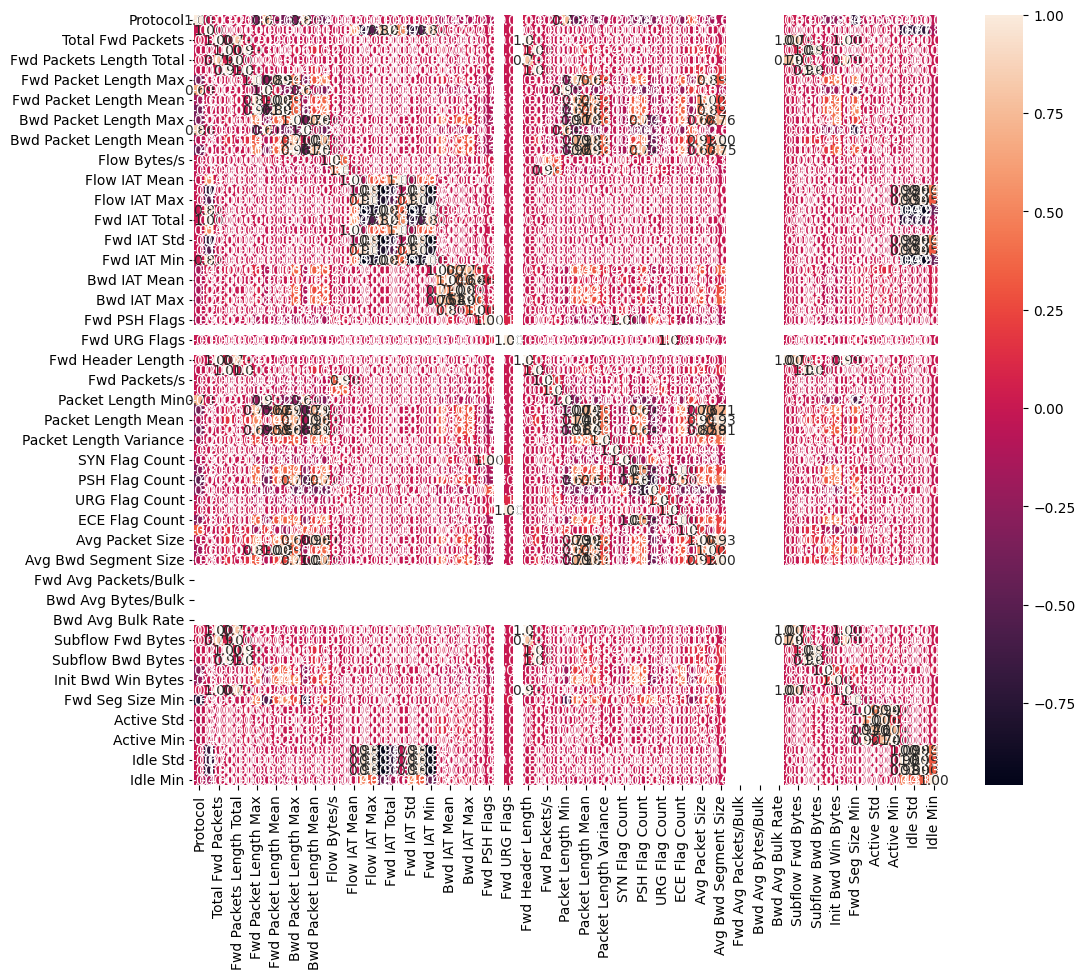

Highly correlated features: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = df.drop(columns=['Label'])
corr_matrix = corr_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.show()

threshold = 0.8
high_corr_features = [col for col in corr_matrix.columns if any(corr_matrix[col] > threshold)]
print(f"Highly correlated features: {high_corr_features}")

In [60]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print("Constant columns:", constant_columns)

df = df.drop(columns=constant_columns)

Constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [61]:
# convert protocol column to categorical
df['Protocol'] = df['Protocol'].astype('category')

# update all values of 0 in protocol to 1
df['Protocol'] = df['Protocol'].apply(lambda x: 1 if x == 0 else x)


In [62]:
X = df.drop(columns=['Label'])
y = df['Label']

In [63]:
y.value_counts()

Label
Benign       5329008
Malicious    1330524
Name: count, dtype: int64

In [43]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6659532 entries, 0 to 6659531
Data columns (total 69 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   Protocol                  category
 1   Flow Duration             int64   
 2   Total Fwd Packets         int32   
 3   Total Backward Packets    int32   
 4   Fwd Packets Length Total  int32   
 5   Bwd Packets Length Total  float64 
 6   Fwd Packet Length Max     int32   
 7   Fwd Packet Length Min     int16   
 8   Fwd Packet Length Mean    float32 
 9   Fwd Packet Length Std     float32 
 10  Bwd Packet Length Max     int32   
 11  Bwd Packet Length Min     int16   
 12  Bwd Packet Length Mean    float32 
 13  Bwd Packet Length Std     float32 
 14  Flow Bytes/s              float64 
 15  Flow Packets/s            float64 
 16  Flow IAT Mean             float32 
 17  Flow IAT Std              float32 
 18  Flow IAT Max              float64 
 19  Flow IAT Min              float64 
 20  Fw